In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# ============================================
# STEP 1: IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import shutil
from pathlib import Path

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load CSV
df = pd.read_csv("/content/drive/MyDrive/sales_data.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (100, 7)


,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


In [4]:
# Display all column names
print("Column Names:")
print(df.columns.tolist())

# Dataset information
df.info()

# Statistical summary
display(df.describe())

# Number of rows and columns
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])



Column Names:
['Date', 'Product', 'Quantity', 'Price', 'Customer_ID', 'Region', 'Total_Sales']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         100 non-null    object
 1   Product      100 non-null    object
 2   Quantity     100 non-null    int64 
 3   Price        100 non-null    int64 
 4   Customer_ID  100 non-null    object
 5   Region       100 non-null    object
 6   Total_Sales  100 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 5.6+ KB


,Quantity,Price,Total_Sales
count,100.000000,100.000000,100.000000
mean,4.780000,25808.510000,123650.480000
std,2.588163,13917.630242,100161.085275
min,1.000000,1308.000000,6540.000000
25%,2.750000,14965.250000,39517.500000
50%,5.000000,24192.000000,97955.500000
75%,7.000000,38682.250000,175792.500000
max,9.000000,49930.000000,373932.000000


Number of Rows: 100
Number of Columns: 7


In [5]:
# Check missing values

missing_values = df.isnull().sum()

print("Missing Values:")
display(missing_values)

if missing_values.sum() == 0:
    print("✓ No missing values found.")
else:
    print("⚠ Missing values found.")

Missing Values:


,0
Date,0
Product,0
Quantity,0
Price,0
Customer_ID,0
Region,0
Total_Sales,0


✓ No missing values found.


In [6]:
# Check duplicate rows

duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

if duplicates == 0:
    print("✓ No duplicate rows found.")
else:
    print("⚠ Duplicate rows found.")

Duplicate Rows: 0
✓ No duplicate rows found.


In [7]:
# Convert Date column to datetime

df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

# Convert numerical columns
df["Quantity"] = pd.to_numeric(
    df["Quantity"],
    errors="coerce"
)

df["Price"] = pd.to_numeric(
    df["Price"],
    errors="coerce"
)

df["Total_Sales"] = pd.to_numeric(
    df["Total_Sales"],
    errors="coerce"
)

# Remove duplicate rows
df = df.drop_duplicates()

# Remove invalid rows
df = df.dropna(
    subset=[
        "Date",
        "Product",
        "Quantity",
        "Price",
        "Total_Sales"
    ]
)

print("Data cleaning completed.")
print("Final shape:", df.shape)

Data cleaning completed.
Final shape: (100, 7)


In [8]:
# Calculate expected sales

calculated_sales = df["Quantity"] * df["Price"]

# Compare with existing Total_Sales
sales_difference = (
    calculated_sales - df["Total_Sales"]
).abs()

# Check whether values match
valid_records = (sales_difference < 0.01).sum()
invalid_records = (sales_difference >= 0.01).sum()

print("Valid Sales Records:", valid_records)
print("Invalid Sales Records:", invalid_records)

if invalid_records == 0:
    print("✓ Sales validation successful.")
else:
    print("⚠ Some sales values need verification.")

Valid Sales Records: 100
Invalid Sales Records: 0
✓ Sales validation successful.


In [9]:
# Total sales
total_sales = df["Total_Sales"].sum()
print(f"Total Sales: ₹{total_sales:,.2f}")

# Total Quantity
total_quantity = df["Quantity"].sum()
print("Total Quantity Sold:", total_quantity)

# Total Orders
total_orders = len(df)
print("Total Orders:", total_orders)

# Average order value
average_order_value = df["Total_Sales"].mean()
print(
    f"Average Order Value: ₹{average_order_value:,.2f}"
)

# Unique customers
unique_customers = df["Customer_ID"].nunique()
print("Unique Customers:", unique_customers)



Total Sales: ₹12,365,048.00
Total Quantity Sold: 478
Total Orders: 100
Average Order Value: ₹123,650.48
Unique Customers: 100


In [10]:
# Prducr Analysis
product_analysis = (
    df.groupby("Product")
      .agg(
          Orders=("Product", "count"),
          Quantity_Sold=("Quantity", "sum"),
          Total_Sales=("Total_Sales", "sum")
      )
      .sort_values(
          "Total_Sales",
          ascending=False
      )
)

display(product_analysis)
top_product = product_analysis["Total_Sales"].idxmax()

top_product_sales = product_analysis[
    "Total_Sales"
].max()

print("Best Performing Product:", top_product)
print(
    f"Sales: ₹{top_product_sales:,.2f}"
)

quantity_by_product = (
    df.groupby("Product")["Quantity"]
      .sum()
      .sort_values(ascending=False)
)

top_quantity_product = quantity_by_product.idxmax()

top_quantity = quantity_by_product.max()

print(
    "Product with Highest Quantity Sold:",
    top_quantity_product
)

print("Quantity Sold:", top_quantity)




,Orders,Quantity_Sold,Total_Sales
Product,,,
Laptop,24,136,3889210
Tablet,26,127,2884340
Phone,20,101,2859394
Headphones,15,48,1384033
Monitor,15,66,1348071


Best Performing Product: Laptop
Sales: ₹3,889,210.00
Product with Highest Quantity Sold: Laptop
Quantity Sold: 136


In [11]:
# Region Analysis
region_analysis = (
    df.groupby("Region")
      .agg(
          Orders=("Region", "count"),
          Quantity_Sold=("Quantity", "sum"),
          Total_Sales=("Total_Sales", "sum")
      )
      .sort_values(
          "Total_Sales",
          ascending=False
      )
)

display(region_analysis)
top_region = region_analysis[
    "Total_Sales"
].idxmax()

top_region_sales = region_analysis[
    "Total_Sales"
].max()

print("Best Performing Region:", top_region)
print(
    f"Regional Sales: ₹{top_region_sales:,.2f}"
)


,Orders,Quantity_Sold,Total_Sales
Region,,,
North,28,147,3983635
South,27,143,3737852
East,19,94,2519639
West,26,94,2123922


Best Performing Region: North
Regional Sales: ₹3,983,635.00


In [12]:
# Monthly sales Analysis
monthly_sales = (
    df.groupby(
        df["Date"].dt.to_period("M")
    )["Total_Sales"]
    .sum()
)

display(monthly_sales)
best_month = monthly_sales.idxmax()

best_month_sales = monthly_sales.max()

print("Best Sales Month:", best_month)

print(
    f"Sales: ₹{best_month_sales:,.2f}"
)



,Total_Sales
Date,
2024-01,4120524
2024-02,2656050
2024-03,4485006
2024-04,1103468


Best Sales Month: 2024-03
Sales: ₹4,485,006.00


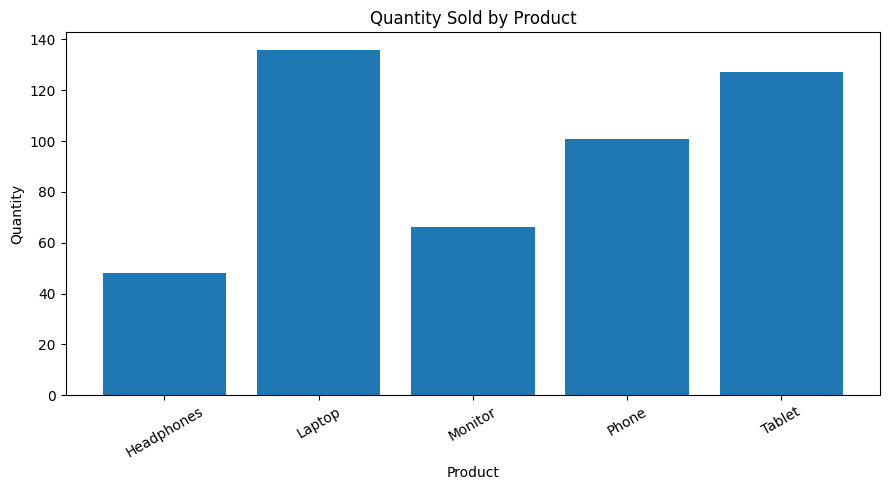

In [13]:
# BAR CHART for Quantity Sold by Product

product_quantity = (
    df.groupby("Product")["Quantity"]
      .sum()
)

plt.figure(figsize=(9, 5))

plt.bar(
    product_quantity.index,
    product_quantity.values
)

plt.title("Quantity Sold by Product")

plt.xlabel("Product")
plt.ylabel("Quantity")

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

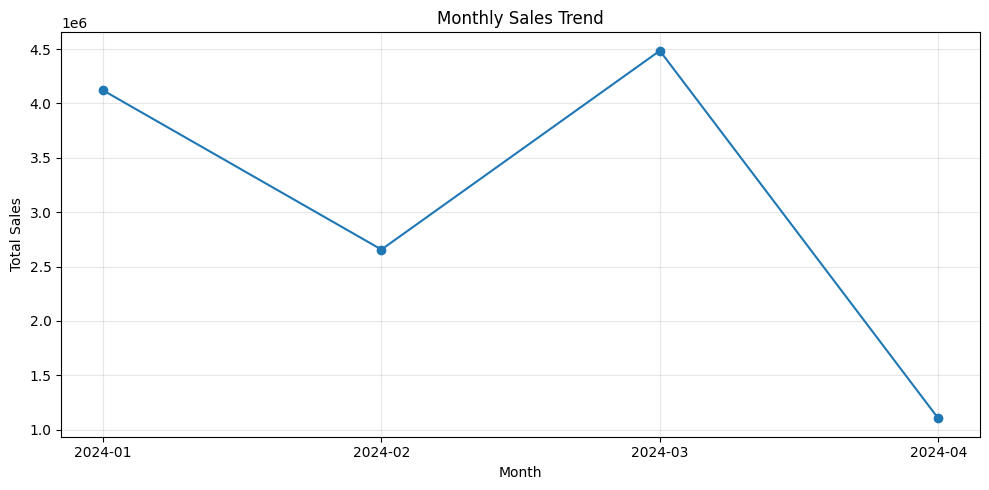

In [14]:
# LINE CHART For Monthly Sales Trend


monthly_sales_plot = (
    df.groupby(
        df["Date"].dt.to_period("M")
    )["Total_Sales"]
    .sum()
)

monthly_sales_plot.index = (
    monthly_sales_plot.index.astype(str)
)

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_sales_plot.index,
    monthly_sales_plot.values,
    marker="o"
)

plt.title("Monthly Sales Trend")

plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

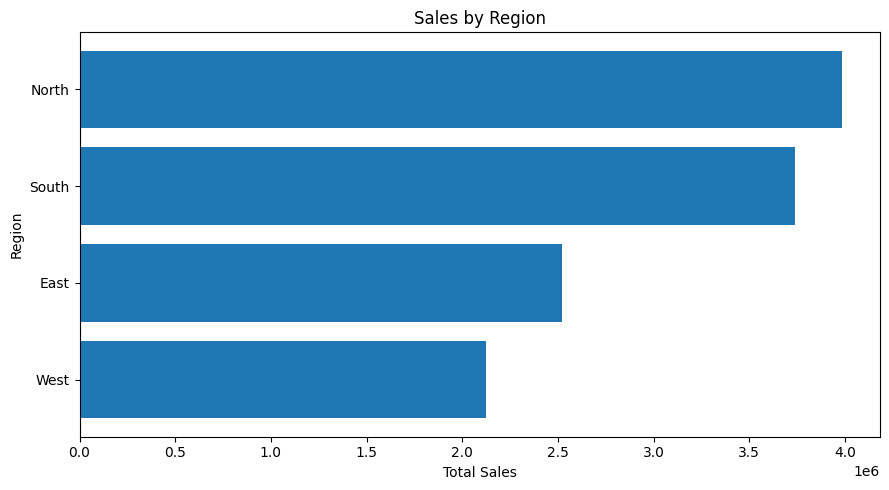

In [15]:
# BAR CHART For Sales by Region


region_sales = (
    df.groupby("Region")["Total_Sales"]
      .sum()
      .sort_values()
)

plt.figure(figsize=(9, 5))

plt.barh(
    region_sales.index,
    region_sales.values
)

plt.title("Sales by Region")

plt.xlabel("Total Sales")
plt.ylabel("Region")

plt.tight_layout()

plt.show()

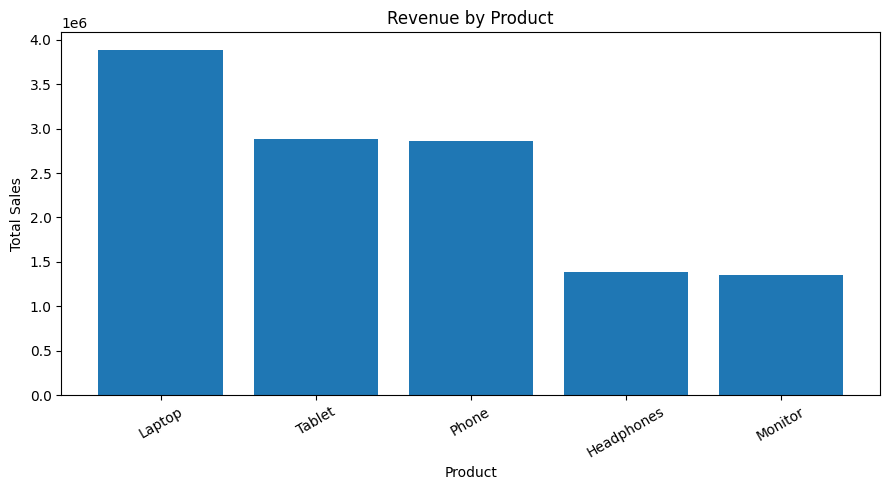

In [16]:

# BAR CHART For Revenue by Product


product_revenue = (
    df.groupby("Product")["Total_Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

plt.bar(
    product_revenue.index,
    product_revenue.values
)

plt.title("Revenue by Product")

plt.xlabel("Product")
plt.ylabel("Total Sales")

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

In [17]:
# BUSINESS INSIGHTS


lowest_product = product_analysis[
    "Total_Sales"
].idxmin()

lowest_product_sales = product_analysis[
    "Total_Sales"
].min()

lowest_region = region_analysis[
    "Total_Sales"
].idxmin()

lowest_region_sales = region_analysis[
    "Total_Sales"
].min()

print("========== BUSINESS INSIGHTS ==========\n")

print(
    f"1. {top_product} is the highest-revenue "
    f"product with ₹{top_product_sales:,.2f} in sales."
)

print(
    f"2. {lowest_product} is the lowest-revenue "
    f"product with ₹{lowest_product_sales:,.2f} in sales."
)

print(
    f"3. {top_quantity_product} has the highest "
    f"quantity sold with {top_quantity} units."
)

print(
    f"4. {top_region} is the strongest region "
    f"with ₹{top_region_sales:,.2f} in sales."
)

print(
    f"5. {lowest_region} has the lowest regional "
    f"sales at ₹{lowest_region_sales:,.2f}."
)

print(
    f"6. {best_month} recorded the highest monthly "
    f"sales of ₹{best_month_sales:,.2f}."
)

========== BUSINESS INSIGHTS ==========

1. Laptop is the highest-revenue product with ₹3,889,210.00 in sales.
2. Monitor is the lowest-revenue product with ₹1,348,071.00 in sales.
3. Laptop has the highest quantity sold with 136 units.
4. North is the strongest region with ₹3,983,635.00 in sales.
5. West has the lowest regional sales at ₹2,123,922.00.
6. 2024-03 recorded the highest monthly sales of ₹4,485,006.00.


In [18]:
# Summary Table

summary = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Total Orders",
        "Total Quantity Sold",
        "Average Order Value",
        "Unique Customers",
        "Best Product",
        "Best Region",
        "Best Month"
    ],

    "Value": [
        f"₹{total_sales:,.2f}",
        total_orders,
        total_quantity,
        f"₹{average_order_value:,.2f}",
        unique_customers,
        top_product,
        top_region,
        str(best_month)
    ]
})

display(summary)

,Metric,Value
0,Total Sales,"₹12,365,048.00"
1,Total Orders,100
2,Total Quantity Sold,478
3,Average Order Value,"₹123,650.48"
4,Unique Customers,100
5,Best Product,Laptop
6,Best Region,North
7,Best Month,2024-03
